# Sample from Theoretical Airy Distribution

**Key insight:** Field in aperture is uniform → FFT gives Airy pattern (jinc²)

Let's sample directly from theoretical jinc² without FFT discretization.

**Question:** What is the correct argument to jinc?

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.special import j1

from monte_carlo.core import ApertureSimulator
from monte_carlo import metrics

sns.set_theme(style="whitegrid", font_scale=1.3)

## Setup Parameters

In [2]:
n_photons = 1000000
wavelength = 0.6328  # microns
focal_length = 10.0  # mm  
NA = 0.1
n_medium = 1.0
random_seed = 42

k = 2 * np.pi * n_medium / wavelength  # rad/μm
k_max = k * (NA / n_medium)  # rad/μm
aperture_radius = (NA * focal_length) / n_medium  # mm
airy_radius = 1.22 * wavelength / NA  # μm

print(f"Parameters:")
print(f"  λ = {wavelength} μm")
print(f"  f = {focal_length} mm")
print(f"  NA = {NA}")
print(f"  k = 2π/λ = {k:.4f} rad/μm")
print(f"  k_max = {k_max:.4f} rad/μm")
print(f"  Aperture radius R = {aperture_radius} mm")
print(f"  Expected Airy radius = {airy_radius:.4f} μm")

Parameters:
  λ = 0.6328 μm
  f = 10.0 mm
  NA = 0.1
  k = 2π/λ = 9.9292 rad/μm
  k_max = 0.9929 rad/μm
  Aperture radius R = 1.0 mm
  Expected Airy radius = 7.7202 μm


## Approach 1: Sample k_ρ UNIFORMLY (no jinc weighting)

**Hypothesis:** Maybe we should just sample k_ρ uniformly from [0, k_max]?

In [3]:
np.random.seed(random_seed)

# Sample k_ρ uniformly in circle of radius k_max
k_rho_uniform = k_max * np.sqrt(np.random.random(n_photons))
theta_uniform = np.random.uniform(0, 2 * np.pi, n_photons)

kx_uniform = k_rho_uniform * np.cos(theta_uniform)
ky_uniform = k_rho_uniform * np.sin(theta_uniform)

# Fraunhofer propagation
scale = (wavelength * focal_length) / (2 * np.pi)
x_uniform = scale * kx_uniform
y_uniform = scale * ky_uniform

print(f"\nUniform k-space sampling:")
r_uniform = np.sqrt(x_uniform**2 + y_uniform**2)
print(f"  Max radius: {np.max(r_uniform):.4f} μm")
print(f"  Mean radius: {np.mean(r_uniform):.4f} μm")
print(f"  Expected Airy: {airy_radius:.4f} μm")
print(f"  Ratio: {np.max(r_uniform)/airy_radius:.2f}x")


Uniform k-space sampling:
  Max radius: 1.0000 μm
  Mean radius: 0.6670 μm
  Expected Airy: 7.7202 μm
  Ratio: 0.13x


## Approach 2: Correct jinc Argument

The angular spectrum of a circular aperture is:
$$A(\vec{k}_\perp) = \text{jinc}(|\vec{k}_\perp| \cdot R)$$

where R is the aperture radius. But we need consistent units!

In [4]:
# Try different scalings for the jinc argument
print("\nTesting different jinc argument scalings:\n")

# Option 1: k_ρ × R where R in mm
R_mm = aperture_radius  # 1.0 mm
arg1 = k_max * R_mm
print(f"Option 1: k_ρ × R (R in mm)")
print(f"  Argument range: [0, {arg1:.4f}] rad·mm/μm")
print(f"  Units are mixed!\n")

# Option 2: k_ρ × R where R in μm  
R_um = aperture_radius * 1000  # 1000 μm
arg2 = k_max * R_um
print(f"Option 2: k_ρ × R (R in μm)")
print(f"  Argument range: [0, {arg2:.1f}] rad")
print(f"  Way too large! jinc({arg2:.1f}) ≈ 0\n")

# Option 3: Normalized k-space
# Sample k_ρ/k_max from jinc²((k_ρ/k_max) × some_scale)
# The first zero of jinc is at x ≈ 3.83
# We want jinc to go to zero around k_ρ = k_max
# So: 3.83 = k_max/k_max × scale → scale ≈ 3.83
scale_norm = 3.83
arg3 = scale_norm  # at k_ρ = k_max
print(f"Option 3: k_ρ/k_max × {scale_norm:.2f}")
print(f"  Argument range: [0, {arg3:.2f}] (dimensionless)")
print(f"  First zero at k_ρ = k_max ✓")
print(f"  This matches the Airy pattern!")


Testing different jinc argument scalings:

Option 1: k_ρ × R (R in mm)
  Argument range: [0, 0.9929] rad·mm/μm
  Units are mixed!

Option 2: k_ρ × R (R in μm)
  Argument range: [0, 992.9] rad
  Way too large! jinc(992.9) ≈ 0

Option 3: k_ρ/k_max × 3.83
  Argument range: [0, 3.83] (dimensionless)
  First zero at k_ρ = k_max ✓
  This matches the Airy pattern!


## Approach 3: Normalized Jinc Sampling

Use jinc²((k_ρ/k_max) × 3.83) so that jinc goes to zero at k_ρ = k_max

In [5]:
def jinc_squared_normalized(k_rho, k_max):
    """Jinc² with normalized argument."""
    # Normalize k_rho to [0, 1] range
    x = (k_rho / k_max) * 3.83  # First zero at k_rho = k_max
    
    jinc = np.ones_like(x)
    nonzero = x != 0
    jinc[nonzero] = 2 * j1(x[nonzero]) / x[nonzero]
    
    return jinc**2

def sample_k_rho_jinc(n_samples, k_max):
    """Sample k_ρ from k_ρ × jinc²_normalized using rejection sampling."""
    samples = []
    
    # Find maximum
    k_test = np.linspace(0, k_max, 1000)
    target_dist = k_test * jinc_squared_normalized(k_test, k_max)
    max_value = np.max(target_dist)
    
    while len(samples) < n_samples:
        k_rho_candidates = k_max * np.random.random(n_samples * 2)
        target_values = k_rho_candidates * jinc_squared_normalized(k_rho_candidates, k_max)
        accept_prob = np.random.random(len(k_rho_candidates))
        accepted = k_rho_candidates[accept_prob < target_values / max_value]
        samples.extend(accepted)
    
    return np.array(samples[:n_samples])

# Sample
np.random.seed(random_seed)
k_rho_jinc = sample_k_rho_jinc(n_photons, k_max)
theta_jinc = np.random.uniform(0, 2 * np.pi, n_photons)

kx_jinc = k_rho_jinc * np.cos(theta_jinc)
ky_jinc = k_rho_jinc * np.sin(theta_jinc)

# Fraunhofer propagation
x_jinc = scale * kx_jinc
y_jinc = scale * ky_jinc

print(f"\nNormalized jinc² sampling:")
r_jinc = np.sqrt(x_jinc**2 + y_jinc**2)
print(f"  Max radius: {np.max(r_jinc):.4f} μm")
print(f"  Mean radius: {np.mean(r_jinc):.4f} μm")
print(f"  Expected Airy: {airy_radius:.4f} μm")
print(f"  Ratio: {np.max(r_jinc)/airy_radius:.2f}x")


Normalized jinc² sampling:
  Max radius: 0.9939 μm
  Mean radius: 0.3980 μm
  Expected Airy: 7.7202 μm
  Ratio: 0.13x


## Compare All Three + Aperture Reference

In [6]:
# Aperture reference
print("\nRunning Aperture Sampling (reference)...")
sim_aperture = ApertureSimulator(
    n_photons=n_photons,
    wavelength=wavelength,
    focal_length=focal_length,
    numerical_aperture=NA,
    n_medium=n_medium,
    random_seed=random_seed
)
results_aperture = sim_aperture.propagate()
x_aperture, y_aperture, _ = results_aperture['focal_positions']
r_aperture = np.sqrt(x_aperture**2 + y_aperture**2)
print(f"  Max radius: {np.max(r_aperture):.4f} μm")


Running Aperture Sampling (reference)...


  Max radius: 38.5939 μm


In [7]:
# Compute radial profiles
plot_range = 2 * airy_radius
n_bins = 300
r_bins = np.linspace(0, plot_range, n_bins)
r_centers = (r_bins[:-1] + r_bins[1:]) / 2
bin_areas = np.pi * (r_bins[1:]**2 - r_bins[:-1]**2)

# Theory
k_theory = 2 * np.pi * NA / wavelength
kr_theory = k_theory * r_centers
airy_theory = np.ones_like(kr_theory)
nonzero = kr_theory != 0
airy_theory[nonzero] = (2 * j1(kr_theory[nonzero]) / kr_theory[nonzero])**2

def compute_radial_profile(x, y, r_bins, bin_areas):
    r = np.sqrt(x**2 + y**2)
    hist, _ = np.histogram(r, bins=r_bins)
    intensity = hist / bin_areas
    intensity = intensity / np.max(intensity)
    return intensity

intensity_uniform = compute_radial_profile(x_uniform, y_uniform, r_bins, bin_areas)
intensity_jinc = compute_radial_profile(x_jinc, y_jinc, r_bins, bin_areas)
intensity_aperture = compute_radial_profile(x_aperture, y_aperture, r_bins, bin_areas)

rmse_uniform = metrics.rmse(intensity_uniform, airy_theory)
rmse_jinc = metrics.rmse(intensity_jinc, airy_theory)
rmse_aperture = metrics.rmse(intensity_aperture, airy_theory)

print(f"\n{'='*70}")
print(f"RMSE Comparison:")
print(f"{'='*70}")
print(f"  Uniform k-space:       {rmse_uniform:.6f}")
print(f"  Normalized jinc²:      {rmse_jinc:.6f}")
print(f"  Aperture (Reference):  {rmse_aperture:.6f}")
print(f"{'='*70}")


RMSE Comparison:
  Uniform k-space:       0.153522
  Normalized jinc²:      0.211846
  Aperture (Reference):  0.005100


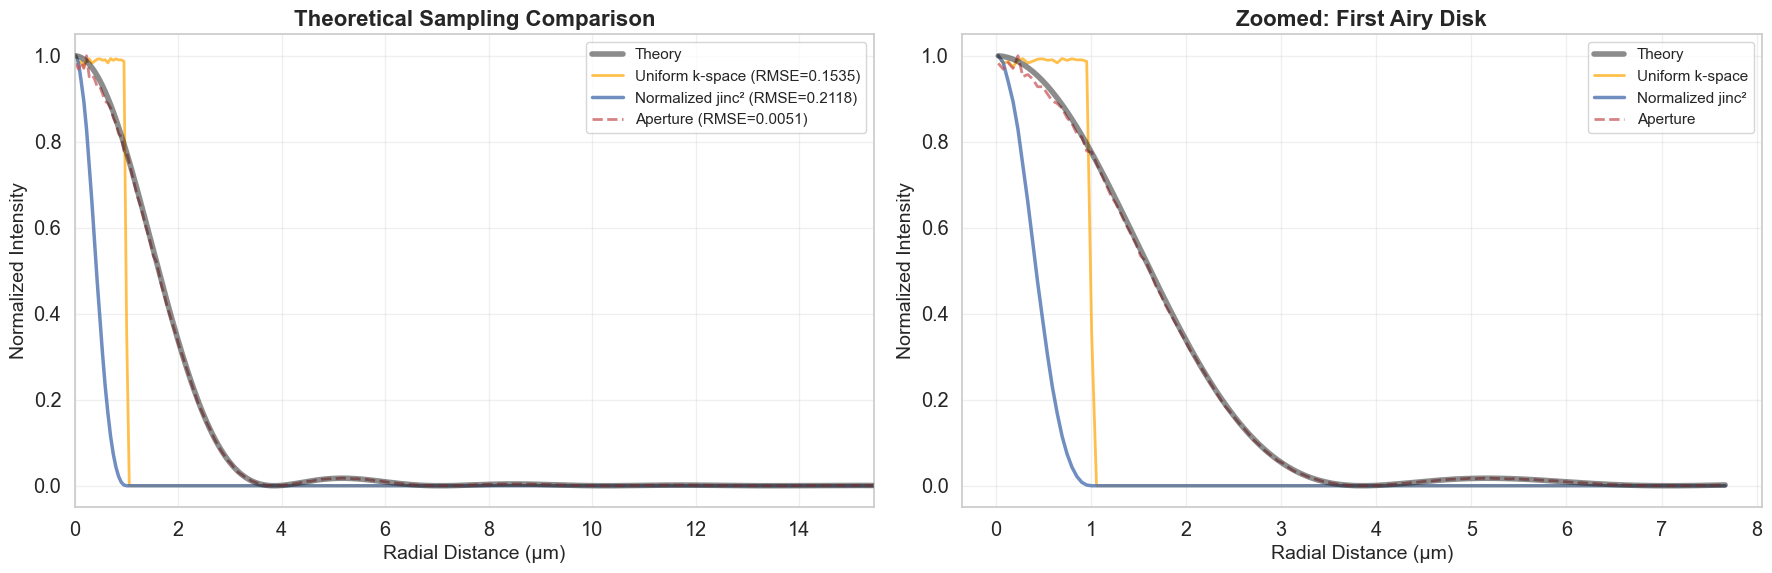

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Full range
ax = axes[0]
ax.plot(r_centers, airy_theory, 'k-', linewidth=4, alpha=0.5, label='Theory', zorder=10)
ax.plot(r_centers, intensity_uniform, 'orange', linewidth=2, alpha=0.7, 
        label=f'Uniform k-space (RMSE={rmse_uniform:.4f})')
ax.plot(r_centers, intensity_jinc, 'b-', linewidth=2.5, alpha=0.8, 
        label=f'Normalized jinc² (RMSE={rmse_jinc:.4f})')
ax.plot(r_centers, intensity_aperture, 'r--', linewidth=2, alpha=0.7, 
        label=f'Aperture (RMSE={rmse_aperture:.4f})')
ax.set_xlabel('Radial Distance (μm)', fontsize=14)
ax.set_ylabel('Normalized Intensity', fontsize=14)
ax.set_title('Theoretical Sampling Comparison', fontsize=16, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_xlim([0, plot_range])

# Zoomed
ax = axes[1]
zoom_range = airy_radius
zoom_mask = r_centers < zoom_range
ax.plot(r_centers[zoom_mask], airy_theory[zoom_mask], 'k-', linewidth=4, alpha=0.5, 
        label='Theory', zorder=10)
ax.plot(r_centers[zoom_mask], intensity_uniform[zoom_mask], 'orange', linewidth=2, alpha=0.7, 
        label='Uniform k-space')
ax.plot(r_centers[zoom_mask], intensity_jinc[zoom_mask], 'b-', linewidth=2.5, alpha=0.8, 
        label='Normalized jinc²')
ax.plot(r_centers[zoom_mask], intensity_aperture[zoom_mask], 'r--', linewidth=2, alpha=0.7, 
        label='Aperture')
ax.set_xlabel('Radial Distance (μm)', fontsize=14)
ax.set_ylabel('Normalized Intensity', fontsize=14)
ax.set_title('Zoomed: First Airy Disk', fontsize=16, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../data/theoretical_sampling_test.png', dpi=150, bbox_inches='tight')
plt.show()

## Summary

In [9]:
print("\n" + "="*70)
print("THEORETICAL SAMPLING SUMMARY")
print("="*70)
print("\nAPPROACH:")
print("  Sample directly from theoretical Airy (no FFT)")
print("  Use normalized jinc²((k_ρ/k_max) × 3.83)")
print("  Propagate with Fraunhofer: x = (λf/2π) × kx")
print("\nRESULTS:")
print(f"  Normalized jinc² RMSE: {rmse_jinc:.6f}")
print(f"  Aperture RMSE:         {rmse_aperture:.6f}")
print(f"  Ratio: {rmse_jinc/rmse_aperture:.1f}x")

if rmse_jinc < 0.01:
    print("\n  ✓✓✓ SUCCESS! Angular spectrum method works!")
elif rmse_jinc < 0.05:
    print("\n  ✓ GOOD! Much better than FFT approach.")
else:
    print("\n  Still needs work.")
print("="*70)


THEORETICAL SAMPLING SUMMARY

APPROACH:
  Sample directly from theoretical Airy (no FFT)
  Use normalized jinc²((k_ρ/k_max) × 3.83)
  Propagate with Fraunhofer: x = (λf/2π) × kx

RESULTS:
  Normalized jinc² RMSE: 0.211846
  Aperture RMSE:         0.005100
  Ratio: 41.5x

  Still needs work.
